# Deep Learning Assignment 1


- Data is loaded from a local `data/` folder.
- Figures are saved into an `outputs/` folder with informative filenames.
- Cells are ordered so dependencies are explicit and minimal.

In [1]:
%matplotlib inline

import os
import outputs
from pathlib import Path
import random
import copy
import gc
import pickle

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples

import optuna
from optuna.pruners import MedianPruner



/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 1. Global Setup, Device, and Paths ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

notebook_dir = Path.cwd()
DATA_ROOT = notebook_dir / "data"
OUTPUTS_DIR = notebook_dir / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# --- 2. Reproducibility Setup ---
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(42)
g = torch.Generator()
g.manual_seed(42)

Using device: cuda


In [3]:
def get_train_val_test_data(validation_size=5000,
                            train_transforms=transforms.ToTensor(),
                            test_transforms=transforms.ToTensor()):
    """
    Load the CIFAR10 dataset and split it into training, validation, and test sets.

    Parameters:
        validation_size (int): Number of samples to use for the validation set.
        train_transforms: Transformations to be applied to the training data.
        test_transforms: Transformations to be applied to the validation and test data.
    """

    # load the training set twice:
    # one copy with train transforms, one copy with test/validation transforms
    full_train_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=False,
        transform=train_transforms
    )

    full_val_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=False,
        transform=test_transforms
    )

    test_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=False,
        download=False,
        transform=test_transforms
    )

    total_train_size = len(full_train_dataset)
    train_size = total_train_size - validation_size

    indices = torch.randperm(total_train_size).tolist()

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(full_train_dataset, train_indices)
    val_dataset = Subset(full_val_dataset, val_indices)

    return train_dataset, val_dataset, test_dataset

In [4]:
train_dataset, val_dataset, test_dataset = get_train_val_test_data()
print("Loaded datasets:")
print("  Train images:", len(train_dataset))
print("  Validation images:", len(val_dataset))
print("  Test images:", len(test_dataset))

/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loaded datasets:
  Train images: 45000
  Validation images: 5000
  Test images: 10000


In [5]:
def save_figure(fig, filename):
    """Save a matplotlib figure to the outputs directory."""
    output_path = OUTPUTS_DIR / filename
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path

def show_images(dataset, num_images=5, title=""): #shows images from the dataset
    """Display sample images from the dataset."""
    label_names = dataset.dataset.classes if hasattr(dataset, "dataset") else dataset.classes

    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))
    fig.suptitle(title)

    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()

        ax = axes[i] if num_images > 1 else axes
        ax.imshow(image)
        ax.set_title(label_names[label])
        ax.axis("off")

    fig.tight_layout()
    return fig

Saved figure: /home/raveco/deep_learning_ass1/outputs/train_samples.png


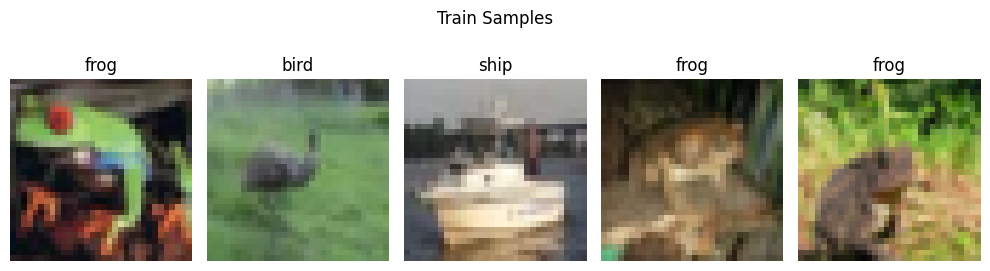

Saved figure: /home/raveco/deep_learning_ass1/outputs/validation_samples.png


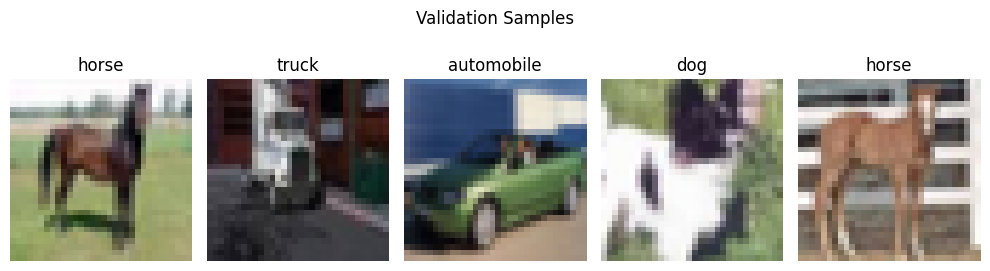

Saved figure: /home/raveco/deep_learning_ass1/outputs/test_samples.png


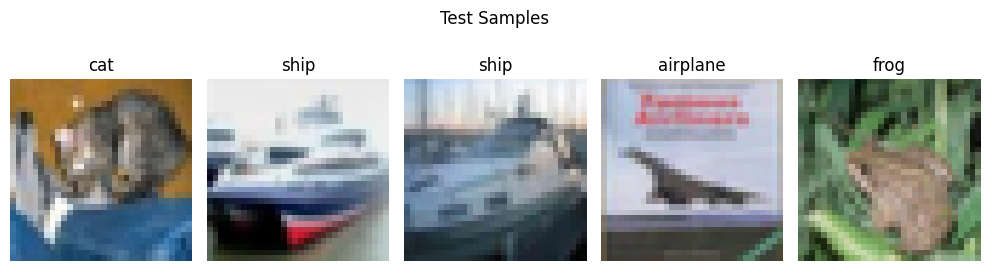

In [6]:
fig = show_images(train_dataset, 5, title="Train Samples")
save_figure(fig, "train_samples.png")
plt.show()

fig = show_images(val_dataset, 5, title="Validation Samples")
save_figure(fig, "validation_samples.png")
plt.show()

fig = show_images(test_dataset, 5, title="Test Samples")
save_figure(fig, "test_samples.png")
plt.show()

Image shape (C, H, W): torch.Size([3, 32, 32])
Label: 0

Channel-wise stats:
Red channel -> min: 0.0431, max: 0.9216, mean: 0.5812
Green channel -> min: 0.0863, max: 0.8863, mean: 0.5949
Blue channel -> min: 0.0353, max: 0.8745, mean: 0.5671
Saved figure: /home/raveco/deep_learning_ass1/outputs/debug_rgb_channels.png


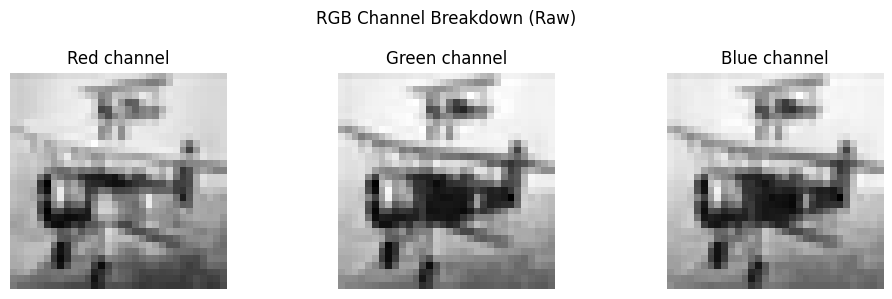

Final image array shape (H, W, C): (32, 32, 3)
Value range: 0.03529412 to 0.92156863
Saved figure: /home/raveco/deep_learning_ass1/outputs/debug_rgb_overlay.png


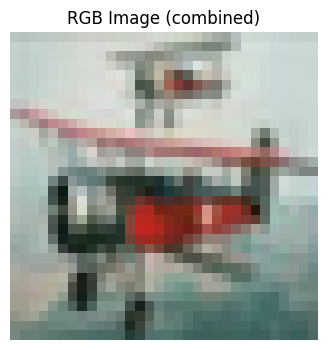

In [7]:
# ===================== DEBUG: IMAGE RGB CHECK =====================

def debug_image_rgb(dataset):
    """Debug: show individual RGB channels and statistics."""
    image, label = dataset[0]  # take first image

    print("Image shape (C, H, W):", image.shape)
    print("Label:", label)

    print("\nChannel-wise stats:")
    for i, color in enumerate(["Red", "Green", "Blue"]):
        print(f"{color} channel -> min: {image[i].min():.4f}, max: {image[i].max():.4f}, mean: {image[i].mean():.4f}")

    # show raw channels
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        axs[i].imshow(image[i], cmap="gray")
        axs[i].set_title(f"{color} channel")
        axs[i].axis("off")

    fig.suptitle("RGB Channel Breakdown (Raw)")
    fig.tight_layout()
    return fig


def debug_rgb_overlay(dataset):
    """Debug: show RGB image overlay."""
    image, _ = dataset[0]

    # convert CHW → HWC for display
    img = image.permute(1, 2, 0).numpy()

    fig = plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("RGB Image (combined)")
    plt.axis("off")

    print("Final image array shape (H, W, C):", img.shape)
    print("Value range:", img.min(), "to", img.max())
    
    return fig


# run debug
train_dataset, val_dataset, test_dataset = get_train_val_test_data()
fig_rgb = debug_image_rgb(train_dataset)
save_figure(fig_rgb, "debug_rgb_channels.png")
plt.show()

fig_overlay = debug_rgb_overlay(train_dataset)
save_figure(fig_overlay, "debug_rgb_overlay.png")
plt.show()

# ================================================================

Saved figure: /home/raveco/deep_learning_ass1/outputs/class_distribution_train_val_test.png


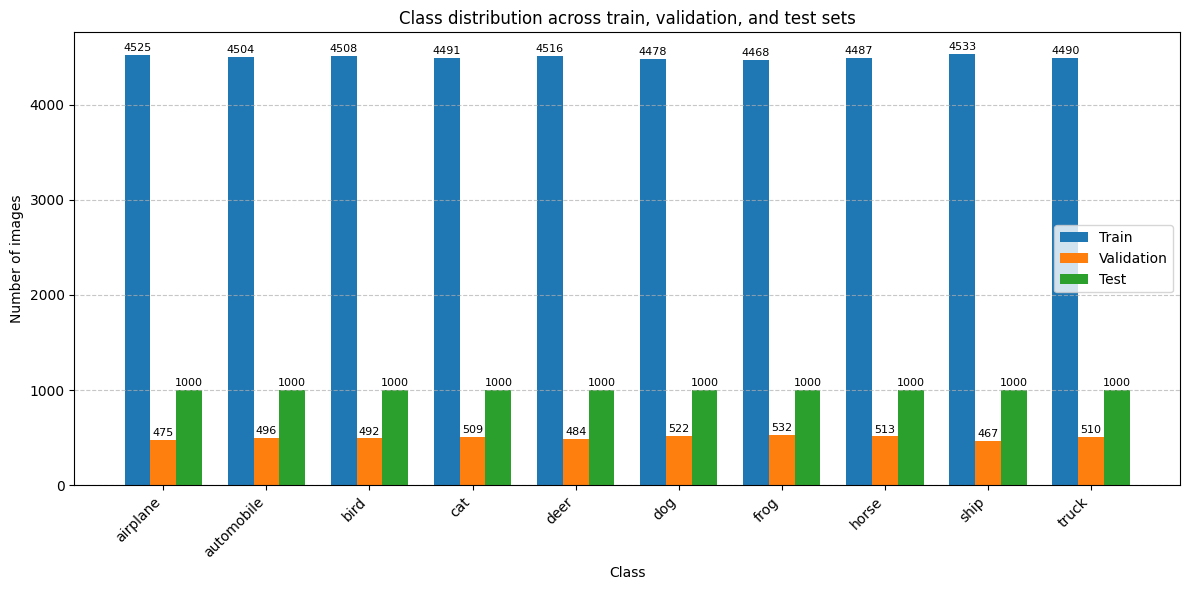

In [8]:
# ===================== PLOT CLASS DISTRIBUTION =====================

def plot_class_distribution(train_dataset, val_dataset, test_dataset):
    """Plot class distribution across train, validation, and test sets."""
    label_names = test_dataset.classes
    num_classes = len(label_names)

    train_counts = np.zeros(num_classes, dtype=int)
    val_counts = np.zeros(num_classes, dtype=int)
    test_counts = np.zeros(num_classes, dtype=int)

    # count train labels
    for idx in train_dataset.indices:
        label = train_dataset.dataset.targets[idx]
        train_counts[label] += 1

    # count validation labels
    for idx in val_dataset.indices:
        label = val_dataset.dataset.targets[idx]
        val_counts[label] += 1

    # count test labels
    for label in test_dataset.targets:
        test_counts[label] += 1

    x = np.arange(num_classes)
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    bars_train = ax.bar(x - bar_width, train_counts, width=bar_width, label="Train")
    bars_val = ax.bar(x, val_counts, width=bar_width, label="Validation")
    bars_test = ax.bar(x + bar_width, test_counts, width=bar_width, label="Test")

    # add numbers on top of bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 20,
                str(int(height)),
                ha='center',
                va='bottom',
                fontsize=8
            )

    add_labels(bars_train)
    add_labels(bars_val)
    add_labels(bars_test)

    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_ylabel("Number of images")
    ax.set_xlabel("Class")
    ax.set_title("Class distribution across train, validation, and test sets")

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    fig.tight_layout()
    
    return fig

train_dataset, val_dataset, test_dataset = get_train_val_test_data()
fig_dist = plot_class_distribution(train_dataset, val_dataset, test_dataset)
save_figure(fig_dist, "class_distribution_train_val_test.png")
plt.show()

Saved figure: /home/raveco/deep_learning_ass1/outputs/rgb_stats_per_class.png


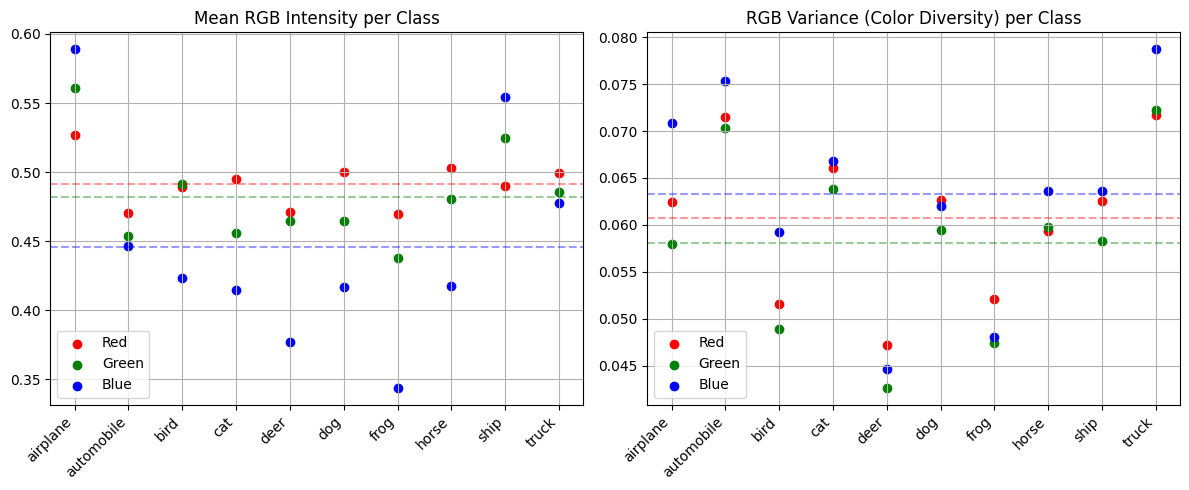

airplane:
  Mean RGB     = [0.52671206 0.56095237 0.588914  ]
  Variance RGB = [0.06244004 0.05794376 0.07085386]

automobile:
  Mean RGB     = [0.47050884 0.45375064 0.44629118]
  Variance RGB = [0.07148147 0.07032654 0.07536416]

bird:
  Mean RGB     = [0.4894061 0.4913817 0.423465 ]
  Variance RGB = [0.05160972 0.04894598 0.05918796]

cat:
  Mean RGB     = [0.49470076 0.45572552 0.4147357 ]
  Variance RGB = [0.06604765 0.06384103 0.06683855]

deer:
  Mean RGB     = [0.47140658 0.464885   0.37709105]
  Variance RGB = [0.04721545 0.04261719 0.04464909]

dog:
  Mean RGB     = [0.49978656 0.46462342 0.4166014 ]
  Variance RGB = [0.06265001 0.05944814 0.06197937]

frog:
  Mean RGB     = [0.46948794 0.43771577 0.3437635 ]
  Variance RGB = [0.05209334 0.04739121 0.04799572]

horse:
  Mean RGB     = [0.50281644 0.48039186 0.41749623]
  Variance RGB = [0.05934748 0.05976135 0.06355725]

ship:
  Mean RGB     = [0.4899111  0.52479106 0.55412185]
  Variance RGB = [0.06252067 0.05824277 0.063616

In [9]:
# ===================== RGB CLASS ANALYSIS =====================

def compute_class_rgb_stats(dataset):
    """
    Computes per-class RGB mean and variance.

    Args:
        dataset: torch.utils.data.Subset (train/val)

    Returns:
        class_means: (num_classes, 3)
        class_vars: (num_classes, 3)
    """
    num_classes = len(dataset.dataset.classes)

    pixel_sum = torch.zeros(num_classes, 3)
    pixel_sq_sum = torch.zeros(num_classes, 3)
    pixel_count = torch.zeros(num_classes)

    for idx in dataset.indices:
        img, label = dataset.dataset[idx]  # (C,H,W)

        img = img.view(3, -1)  # flatten → (3, pixels)

        pixel_sum[label] += img.sum(dim=1)
        pixel_sq_sum[label] += (img ** 2).sum(dim=1)
        pixel_count[label] += img.shape[1]

    class_means = pixel_sum / pixel_count.unsqueeze(1)
    class_vars = (pixel_sq_sum / pixel_count.unsqueeze(1)) - class_means**2

    return class_means.numpy(), class_vars.numpy()


def plot_rgb_stats(class_means, class_vars, class_names):
    """Plot RGB statistics (mean and variance) per class."""
    x = np.arange(len(class_names))
    mean_R = class_means[:, 0].mean()
    mean_G = class_means[:, 1].mean()
    mean_B = class_means[:, 2].mean()

    var_R = class_vars[:, 0].mean()
    var_G = class_vars[:, 1].mean()
    var_B = class_vars[:, 2].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---- Mean ----
    axes[0].scatter(x, class_means[:, 0], color='r', label="Red")
    axes[0].scatter(x, class_means[:, 1], color='g', label="Green")
    axes[0].scatter(x, class_means[:, 2], color='b', label="Blue")
    axes[0].set_title("Mean RGB Intensity per Class")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True)

    axes[0].axhline(mean_R, color='r', linestyle='--', alpha=0.4)
    axes[0].axhline(mean_G, color='g', linestyle='--', alpha=0.4)
    axes[0].axhline(mean_B, color='b', linestyle='--', alpha=0.4)

    # ---- Variance ----
    axes[1].scatter(x, class_vars[:, 0], color='r', label="Red")
    axes[1].scatter(x, class_vars[:, 1], color='g', label="Green")
    axes[1].scatter(x, class_vars[:, 2], color='b', label="Blue")
    axes[1].set_title("RGB Variance (Color Diversity) per Class")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True)

    axes[1].axhline(var_R, color='r', linestyle='--', alpha=0.4)
    axes[1].axhline(var_G, color='g', linestyle='--', alpha=0.4)
    axes[1].axhline(var_B, color='b', linestyle='--', alpha=0.4)

    fig.tight_layout()
    return fig


# ---- RUN ANALYSIS ----
class_means, class_vars = compute_class_rgb_stats(train_dataset)
fig_rgb_stats = plot_rgb_stats(class_means, class_vars, train_dataset.dataset.classes)
save_figure(fig_rgb_stats, "rgb_stats_per_class.png")
plt.show()

# Optional: print numeric values (useful for report)
for i, cls in enumerate(train_dataset.dataset.classes):
    print(f"{cls}:")
    print(f"  Mean RGB     = {class_means[i]}")
    print(f"  Variance RGB = {class_vars[i]}")
    print()

# =============================================================

Saved figure: /home/raveco/deep_learning_ass1/outputs/pca_with_silhouette_table.png


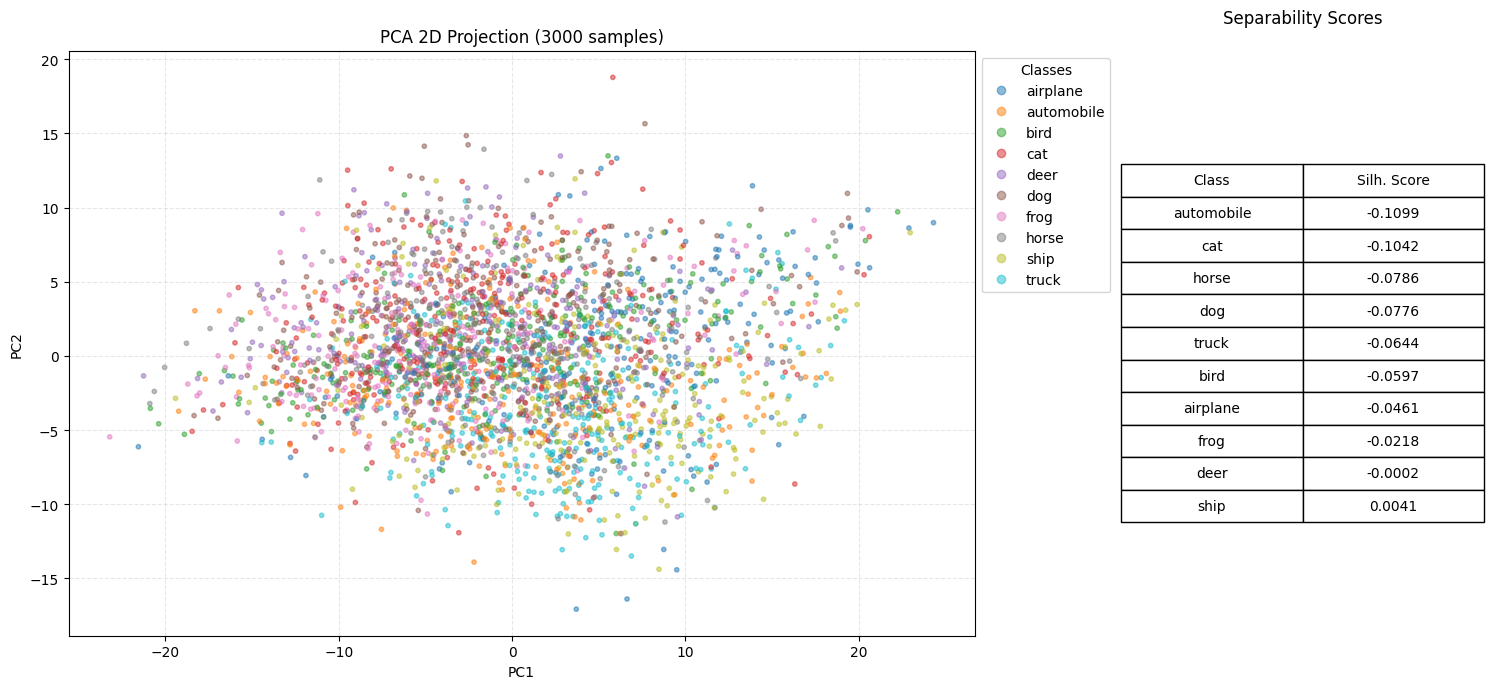

In [10]:
def plot_combined_analysis(dataset, num_samples=3000):
    """
    Computes PCA and Silhouette scores together and plots them side-by-side.
    """
    # 1. Prepare Data
    images, labels = [], []
    indices = dataset.indices[:num_samples]
    for idx in indices:
        img, lbl = dataset.dataset[idx]
        images.append(img.view(-1).numpy())
        labels.append(lbl)
    
    images = np.array(images)
    labels = np.array(labels)
    class_names = dataset.dataset.classes

    # 2. Compute PCA
    pca = PCA(n_components=2)
    projected = pca.fit_transform(images)

    # 3. Compute Silhouette Scores
    sample_scores = silhouette_samples(images, labels)
    class_scores = []
    for i in range(len(class_names)):
        avg_score = np.mean(sample_scores[labels == i])
        class_scores.append([class_names[i], f"{avg_score:.4f}"])
    
    # Sort table by score (lowest to highest) for the plot
    class_scores.sort(key=lambda x: float(x[1]))

    # 4. Plotting
    # Create a figure with extra width for the table
    fig, (ax_plot, ax_table) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [3, 1]})

    # Scatter Plot
    scatter = ax_plot.scatter(projected[:, 0], projected[:, 1], c=labels, cmap='tab10', alpha=0.5, s=10)
    handles, _ = scatter.legend_elements()
    ax_plot.legend(handles, class_names, title="Classes", loc="upper left", bbox_to_anchor=(1, 1))
    ax_plot.set_title(f"PCA 2D Projection ({num_samples} samples)")
    ax_plot.set_xlabel("PC1")
    ax_plot.set_ylabel("PC2")
    ax_plot.grid(True, linestyle='--', alpha=0.3)

    # Table Plot
    ax_table.axis('off')
    table = ax_table.table(
        cellText=class_scores, 
        colLabels=["Class", "Silh. Score"], 
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8) # Adjust scaling for readability
    ax_table.set_title("Separability Scores", pad=20)

    fig.tight_layout()
    return fig

# Run the combined analysis
fig_combined = plot_combined_analysis(train_dataset, num_samples=3000)
save_figure(fig_combined, "pca_with_silhouette_table.png")
plt.show()

In [11]:
def train(model, optimizer, loss_fn, train_loader, val_loader=None, epochs=10, device=device, scheduler=None, trial=None):
    model.to(device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()
        
        if scheduler is not None:
            scheduler.step()
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_train / total_train
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if val_loader:
            model.eval()
            val_running_loss, correct_val, total_val = 0.0, 0, 0
            with torch.no_grad():
                for v_in, v_lab in val_loader:
                    v_in, v_lab = v_in.to(device), v_lab.to(device)
                    v_out = model(v_in)
                    val_running_loss += loss_fn(v_out, v_lab).item() * v_in.size(0)
                    _, v_pred = v_out.max(1)
                    total_val += v_lab.size(0)
                    correct_val += v_pred.eq(v_lab).sum().item()
            
            val_acc = correct_val / total_val
            history["val_loss"].append(val_running_loss / len(val_loader.dataset))
            history["val_acc"].append(val_acc)
            
            # --- OPTUNA PRUNING LOGIC ---
            if trial is not None:
                trial.report(val_acc, epoch)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
                    
    return history


def test(model, test_loader, loss_fn, device="cuda"):
    """
    Evaluate the trained model on the test dataset.

    Parameters:
        model: The trained model to evaluate.
        test_loader: DataLoader providing the test data in batches.
        loss_fn: The loss function used to compute the test loss.
        device (str): Device for computation (e.g., "cuda" or "cpu").

    Returns:
        average_loss: Average loss on the test set.
        accuracy: Classification accuracy on the test set.
    """
    model.to(device)
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    average_loss = test_loss / len(test_loader.dataset)
    accuracy = correct / total
    
    return average_loss, accuracy

In [12]:
def init_weights(model, init_type='kaiming'):
    def init_func(m):
        if isinstance(m, nn.Linear):
            if init_type == 'kaiming':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif init_type == 'xavier':
                nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    model.apply(init_func)

## Model Definitions

The following cells contain commented-out model architectures that can be uncommented and used as needed.

In [13]:
class VanillaMLP(nn.Module):
    def __init__(self, input_size=3072, hidden_dims=[512, 256], num_classes=10, activation_name='relu'):
        super(VanillaMLP, self).__init__()
        
        # Expanded activation functions
        acts = {
            'relu': nn.ReLU(), 'leaky_relu': nn.LeakyReLU(0.01), 
            'elu': nn.ELU(), 'sigmoid': nn.Sigmoid(), 'tanh': nn.Tanh()
        }
        activation = acts.get(activation_name.lower(), nn.ReLU())
        
        layers = []
        prev_dim = input_size
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(activation)
            prev_dim = dim
        
        layers.append(nn.Linear(prev_dim, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1) 
        return self.model(x)


# ## Phase A: Vanilla Architecture Search (Power of 2 & Funnel)

# 1. Predefined Power of 2 values (Index 0 to 5)
# This search will start fresh every time unless FRESH_START is set to False.
power_of_2 = [32, 64, 128, 256, 512, 1024]

def objective_a(trial):
    
    n_layers = trial.suggest_int("n_layers", 1, 4)
    hidden_dims = []
    
    # We track the index instead of the value to keep Optuna happy
    # Start with the highest possible index (5 -> 1024)
    max_idx = 5 
    
    for i in range(n_layers):
        # Optuna suggests an index from 0 to the current max_idx
        # This keeps the search space "static" enough for Optuna
        idx = trial.suggest_int(f"layer_{i}_idx", 0, max_idx)
        
        dim = power_of_2[idx]
        hidden_dims.append(dim)
        
        # Update max_idx so the NEXT layer cannot be larger than this one
        max_idx = idx 
    
    # --- Hyperparameters & Training Settings ---
    activation_name = trial.suggest_categorical("activation", ["relu", "leaky_relu", "elu", "sigmoid", "tanh"])
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    scheduler_name = trial.suggest_categorical("scheduler", ["none", "cosine", "step"])
    
    batch_size = 128
    epochs = 50

    model = VanillaMLP(hidden_dims=hidden_dims, activation_name=activation_name).to(device)
    init_weights(model, init_type='kaiming')
    
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        
    # --- Schedulers ---
    if scheduler_name == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_name == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    else:
        scheduler = None
        
    loss_fn = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    history = train(model, optimizer, loss_fn, train_loader, val_loader, epochs=epochs, trial=trial, scheduler=scheduler)
    
    # --- SAVE ALL STATS PER EPOCH ---
    trial.set_user_attr("history", history)
    
    return max(history["val_acc"])

# --- PERSISTENCE & EXECUTION LOGIC ---
FRESH_START = True # Set to False to skip training and load existing best weights
RESULTS_PATH = OUTPUTS_DIR / "phase_a_results.pkl"
BEST_MODEL_PATH = OUTPUTS_DIR / "vanilla_best.pth"

if not FRESH_START and RESULTS_PATH.exists():
    print("📂 Loading previous results and weights...")
    with open(RESULTS_PATH, "rb") as f:
        saved_data = pickle.load(f)
    best_params_a = saved_data['best_params']
    best_value_a = saved_data['best_value']
    print(f"✅ Loaded Best Parameters (Acc: {best_value_a:.4f})")
else:
    print("🚀 Starting a Fresh 50-Epoch Optuna Study...")
    
    # Pruner gets 10 warmup steps since we are doing 50 epochs now
    study_a = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
    study_a.optimize(objective_a, n_trials=30)
    
    best_params_a = study_a.best_params
    best_value_a = study_a.best_value

    # Save the best parameters
    with open(RESULTS_PATH, "wb") as f:
        pickle.dump({'best_params': best_params_a, 'best_value': best_value_a}, f)
    print(f"💾 Results saved to {RESULTS_PATH}")

# Reconstruct best configurations for use in Phase B
best_hidden_dims_a = [power_of_2[best_params_a[f"layer_{i}_idx"]] for i in range(best_params_a["n_layers"])]
best_act_a = best_params_a["activation"]
best_lr_a = best_params_a["lr"]
best_opt_a = best_params_a["optimizer"]
best_scheduler_a = best_params_a.get("scheduler", "none")

[I 2026-04-28 21:25:30,798] A new study created in memory with name: no-name-da0fba95-2b1f-4c2c-9318-ebfb7140ec5a


🚀 Starting a Fresh 50-Epoch Optuna Study...


[I 2026-04-28 21:30:22,473] Trial 0 finished with value: 0.5388 and parameters: {'n_layers': 3, 'layer_0_idx': 4, 'layer_1_idx': 2, 'layer_2_idx': 1, 'activation': 'leaky_relu', 'lr': 0.000119365302534025, 'optimizer': 'adam', 'scheduler': 'cosine'}. Best is trial 0 with value: 0.5388.
[I 2026-04-28 21:35:14,957] Trial 1 finished with value: 0.4382 and parameters: {'n_layers': 4, 'layer_0_idx': 1, 'layer_1_idx': 1, 'layer_2_idx': 1, 'layer_3_idx': 0, 'activation': 'tanh', 'lr': 0.00038884583763277577, 'optimizer': 'sgd', 'scheduler': 'step'}. Best is trial 0 with value: 0.5388.
[I 2026-04-28 21:39:54,360] Trial 2 finished with value: 0.4626 and parameters: {'n_layers': 2, 'layer_0_idx': 1, 'layer_1_idx': 1, 'activation': 'relu', 'lr': 0.02497865558570121, 'optimizer': 'sgd', 'scheduler': 'none'}. Best is trial 0 with value: 0.5388.
[I 2026-04-28 21:45:02,517] Trial 3 finished with value: 0.5116 and parameters: {'n_layers': 2, 'layer_0_idx': 2, 'layer_1_idx': 2, 'activation': 'elu', 'lr

💾 Results saved to /home/raveco/deep_learning_ass1/outputs/phase_a_results.pkl


In [14]:
# Assuming OUTPUTS_DIR is already defined as a Path object
MODEL_SAVE_DIR = OUTPUTS_DIR / "models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Weights will be saved to: {MODEL_SAVE_DIR}")

Weights will be saved to: /home/raveco/deep_learning_ass1/outputs/models


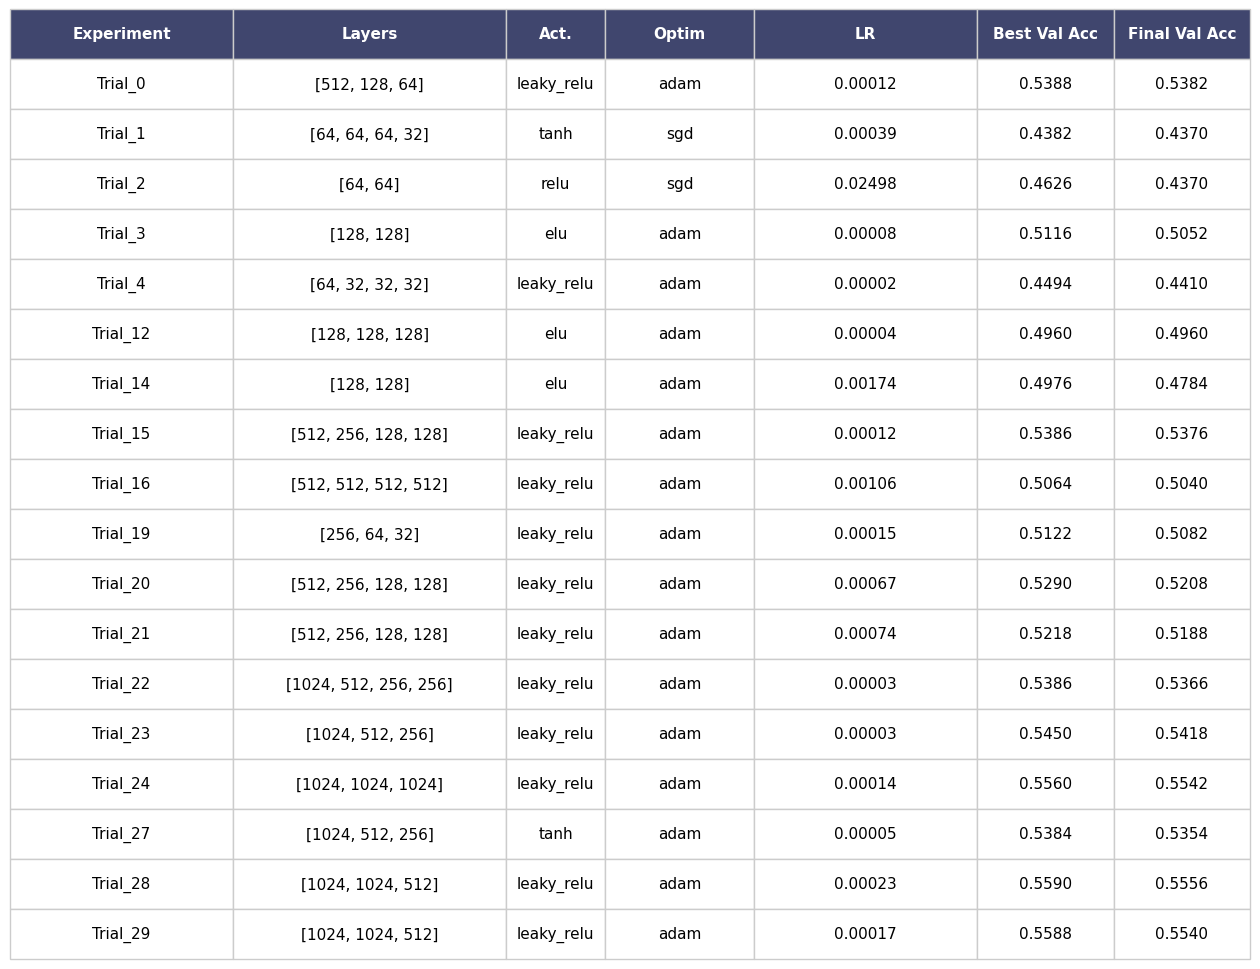

✅ Modified table saved to: outputs/phase_a_summary_table.png


In [18]:
def save_results_as_image(results_dict, outputs_dir="outputs", filename="summary_table.png"):
    if not results_dict:
        print("Error: The results_log is empty.")
        return

    # 1. Process Data (Removed 'Init')
    summary_list = []
    for name, data in results_dict.items():
        h = data['history']
        conf = data['config']
        
        if conf.get('scheduler') == 'step':
            lr_display = f"{conf['lr']} -> 0.00025"
        else:
            lr_display = f"{conf['lr']:.5f}" # Increased precision

        summary_list.append({
            "Experiment": name,
            "Layers": str(conf['hidden_dims']),
            "Act.": conf['activation'],
            "Optim": conf['optimizer'],
            "LR": lr_display,
            "Best Val Acc": f"{max(h['val_acc']):.4f}",
            "Final Val Acc": f"{h['val_acc'][-1]:.4f}"
        })
    
    df = pd.DataFrame(summary_list)

    # 2. Adjusted Plotting
    fig, ax = plt.subplots(figsize=(16, 10)) 
    ax.axis('off') 
    
    header_color = "#40466e" 
    
    # Updated widths: Removed one column and widened LR (0.12 -> 0.18)
    col_widths = [0.18, 0.22, 0.08, 0.12, 0.18, 0.11, 0.11]

    table = ax.table(
        cellText=df.values, 
        colLabels=df.columns, 
        cellLoc='center', 
        loc='center',
        colWidths=col_widths,
        colColours=[header_color] * len(df.columns)
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11) 
    table.scale(1, 3.0) 
    
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.get_text().set_color('white')
            cell.get_text().set_weight('bold')
        cell.set_edgecolor('#CCCCCC')

    out_path = Path(outputs_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    final_save_path = out_path / filename
    
    plt.savefig(final_save_path, bbox_inches='tight', dpi=300)
    plt.show() 
    
    print(f"✅ Modified table saved to: {final_save_path}")


results_log = {}

for trial in study_a.trials:
    if trial.state.name == "COMPLETE":
        # Check if the trial actually has the saved history attribute
        if "history" in trial.user_attrs:
            n_layers = trial.params['n_layers']
            hidden_dims = [power_of_2[trial.params[f"layer_{i}_idx"]] for i in range(n_layers)]
            
            results_log[f"Trial_{trial.number}"] = {
                "history": trial.user_attrs["history"], # Pull the REAL history
                "config": {
                    "hidden_dims": hidden_dims,
                    "activation": trial.params["activation"],
                    "optimizer": trial.params["optimizer"],
                    "lr": trial.params["lr"]
                }
            }


# Now call the plotting function
save_results_as_image(results_log, filename="phase_a_summary_table.png")

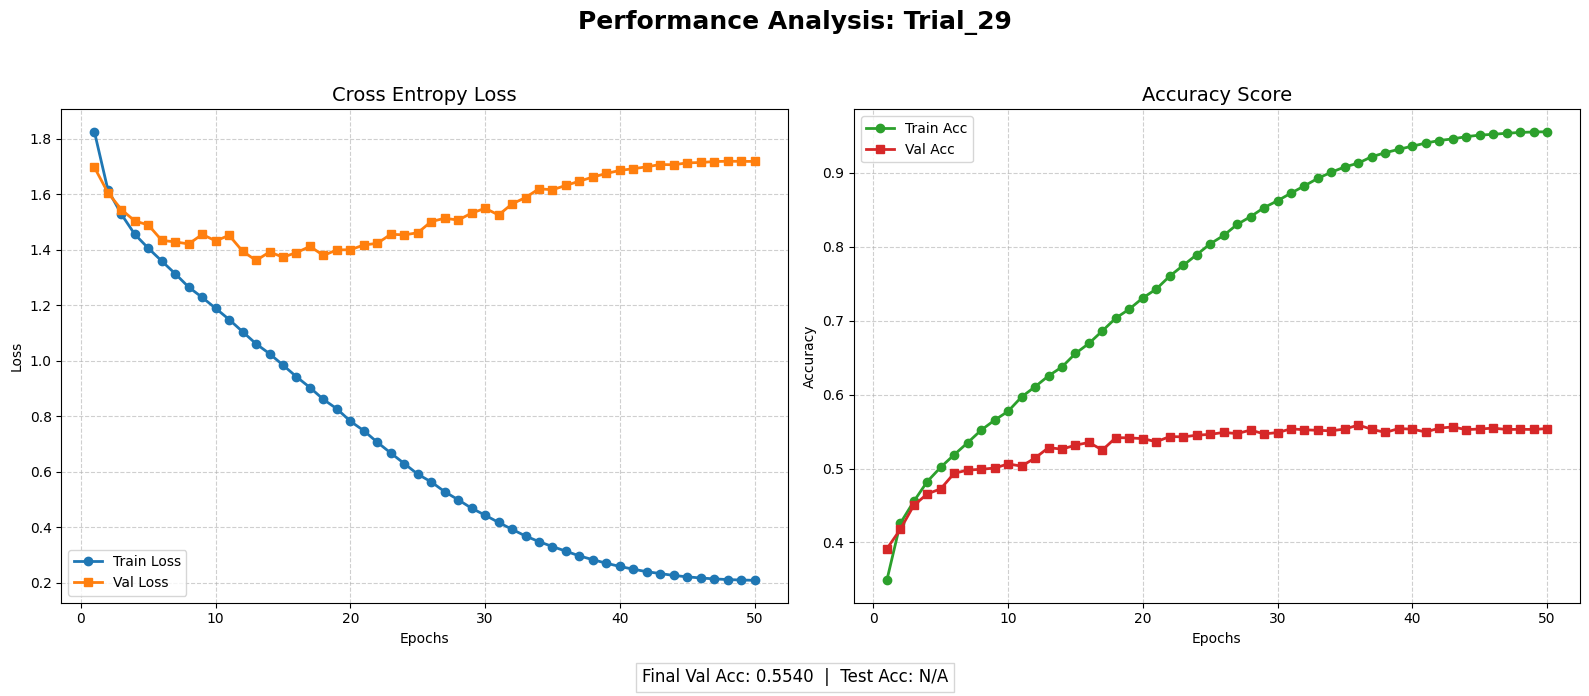

📊 Visualization for Trial_29 saved to: /home/raveco/deep_learning_ass1/outputs/Trial_29_performance.png


In [20]:
def plot_training_results(results_dict, exp_name=None):
    """
    Plots results. If exp_name is None, it automatically picks the last trained model.
    """
    # 1. Automatic "Latest" Detection
    if exp_name is None:
        # Get the last key added to the dictionary
        exp_name = list(results_dict.keys())[-1]
    
    data = results_dict[exp_name]
    history = data['history']
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 2. Set up the figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Performance Analysis: {exp_name}', fontsize=18, fontweight='bold')

    # --- Plot (a): Loss (Training vs Validation) ---
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 's-', label='Val Loss', color='#ff7f0e', linewidth=2)
    ax1.set_title('Cross Entropy Loss', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Plot (b): Accuracy (Training vs Validation) ---
    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc', color='#2ca02c', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 's-', label='Val Acc', color='#d62728', linewidth=2)
    ax2.set_title('Accuracy Score', fontsize=14)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    
    # Optional: Plot the Test Accuracy as a horizontal dashed line if it exists
    if 'test_acc' in data:
        ax2.axhline(y=data['test_acc'], color='black', linestyle='--', alpha=0.5, label=f"Test Acc: {data['test_acc']:.4f}")
    
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    # 3. Add a "Metadata" footer with the Final Results
    # We wrap the values in float() to ensure the :.4f formatting works
    val_acc_val = float(history['val_acc'][-1]) if history['val_acc'][-1] is not None else 0.0
    
    test_acc_raw = data.get('test_acc', 'N/A')
    test_acc_display = f"{float(test_acc_raw):.4f}" if isinstance(test_acc_raw, (int, float)) else "N/A"

    final_txt = (f"Final Val Acc: {val_acc_val:.4f}  |  "
                 f"Test Acc: {test_acc_display}")
    fig.text(0.5, 0.02, final_txt, ha='center', fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='#CCCCCC'))

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    # 4. Save to outputs
    save_path = Path(OUTPUTS_DIR) / f"{exp_name}_performance.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"📊 Visualization for {exp_name} saved to: {save_path}")

# --- Example Usage ---
# This will automatically find "Chosen_VanillaMLP" if it was the last thing you ran!
plot_training_results(results_log)

ImprovedMLP


In [21]:
# 1. Calculate stats from the already loaded train_dataset
# We use a temporary loader to iterate through the data
temp_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False)

mean = 0.0
std = 0.0
for images, _ in temp_loader:
    # images: [batch, 3, 32, 32]
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

mean /= len(train_dataset)
std /= len(train_dataset)

print(f"Computed Mean: {mean.tolist()}")
print(f"Computed Std: {std.tolist()}")

# 2. Define the new transforms using computed stats
train_transform_improved = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform_improved = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Re-running your specific function with the new logic
train_dataset, val_dataset, test_dataset = get_train_val_test_data(
    train_transforms=train_transform_improved,
    test_transforms=test_transform_improved
)

# Re-create loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


print("✅ Data re-loaded with improved transforms and normalization.")

Computed Mean: [0.49139371514320374, 0.48208820819854736, 0.4462636709213257]
Computed Std: [0.20229408144950867, 0.19948092103004456, 0.2010098546743393]


/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


✅ Data re-loaded with improved transforms and normalization.


In [22]:
class ImprovedMLP(nn.Module):
    def __init__(self, hidden_dims, num_class=10, dropout_p=0.15, use_batchnorm=True, act_type="relu", input_size=3*32*32):
        super(ImprovedMLP, self).__init__()
        
        acts = {
            'relu': nn.ReLU(), 'leaky_relu': nn.LeakyReLU(0.01), 
            'elu': nn.ELU(), 'sigmoid': nn.Sigmoid(), 'tanh': nn.Tanh()
        }
        activation = acts.get(act_type.lower(), nn.ReLU())
        
        dims = [input_size] + hidden_dims
        layers = []
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            
            layers.append(activation)
            
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
        
        self.network = nn.Sequential(*layers)
        self.output_layer = nn.Linear(dims[-1], num_class)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.output_layer(self.network(x))

def objective_b(trial):
    # 1. Suggest Regularization Params
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    
    # 2. Suggest Augmentation Params
    crop_scale = trial.suggest_float("crop_scale", 0.7, 1.0)
    rotation_deg = trial.suggest_int("rotation_deg", 0, 45)
    
    # Dynamic Transform for this specific trial
    trial_transform = transforms.Compose([
        transforms.RandomRotation(rotation_deg),
        transforms.RandomResizedCrop(32, scale=(crop_scale, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std) # Relies on global mean/std defined earlier
    ])
    
    trial_train_dataset, trial_val_dataset, _ = get_train_val_test_data(
        train_transforms=trial_transform,
        test_transforms=test_transform_improved
    )
    
    batch_size = 128
    train_loader = DataLoader(trial_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(trial_val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # 3. Model with Hardcoded Phase A Structure
    model = ImprovedMLP(
        hidden_dims=best_hidden_dims_a,
        act_type=best_act_a,
        dropout_p=dropout_p,
        use_batchnorm=use_batchnorm
    ).to(device)
    
    # Reusing Phase A's best LR and Optimizer
    if best_opt_a == "adam": optimizer = torch.optim.Adam(model.parameters(), lr=best_lr_a)
    elif best_opt_a == "sgd": optimizer = torch.optim.SGD(model.parameters(), lr=best_lr_a, momentum=0.9)
    else: optimizer = torch.optim.RMSprop(model.parameters(), lr=best_lr_a)
        
    loss_fn = nn.CrossEntropyLoss()
    
    # 4. Train with Pruning
    history = train(model, optimizer, loss_fn, train_loader, val_loader, epochs=15, device=device, trial=trial)
    return max(history["val_acc"])

# Execute Phase B
print("\n🚀 Starting Phase B: Regularization & Augmentation Search")
pruner_b = MedianPruner(n_startup_trials=5, n_warmup_steps=5)
study_b = optuna.create_study(direction="maximize", pruner=pruner_b, study_name="Phase_B_Improved")
study_b.optimize(objective_b, n_trials=30)

# Summarize and Save Phase B
best_params_b = study_b.best_params
print(f"\n✅ Phase B Complete! Best Validation Acc: {study_b.best_value:.4f}")
print("Best Regularization Parameters:")
for key, value in best_params_b.items():
    print(f"    {key}: {value}")

df_b = study_b.trials_dataframe()
df_b.to_csv(OUTPUTS_DIR / "phase_b_summary.csv", index=False)
with open(OUTPUTS_DIR / "study_b.pkl", "wb") as f:
    pickle.dump(study_b, f)

[I 2026-04-28 23:15:44,118] A new study created in memory with name: Phase_B_Improved



🚀 Starting Phase B: Regularization & Augmentation Search


[W 2026-04-28 23:17:54,894] Trial 0 failed with parameters: {'dropout_p': 0.2508091702247065, 'use_batchnorm': False, 'crop_scale': 0.9329420872251719, 'rotation_deg': 40} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_3680470/1323129501.py", line 74, in objective_b
    history = train(model, optimizer, loss_fn, train_loader, val_loader, epochs=15, device=device, trial=trial)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3680470/3034455468.py", line 9, in train
    for inputs, labels in train_loader:
  File "/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 733, in __next__
    data = self._next_da

KeyboardInterrupt: 

In [ ]:
# --- 1. Setup Directories & Data ---
IMP_MODEL_SAVE_DIR = Path("outputs/improved/models")
IMP_MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
IMP_RESULTS_FILE = "improved_mlp_results.pkl"

# Get datasets
train_dataset_aug, val_dataset, test_dataset = get_train_val_test_data(
    train_transforms=train_transform_improved, 
    test_transforms=test_transform_improved
)
train_dataset_clean, _, _ = get_train_val_test_data(
    train_transforms=test_transform_improved, 
    test_transforms=test_transform_improved
)

# Load existing results
try:
    with open(IMP_RESULTS_FILE, "rb") as f:
        improved_log = pickle.load(f)
    print(f"✅ Loaded existing results. skipping {len(improved_log)} experiments.")
except FileNotFoundError:
    improved_log = {}
    print("info: No existing results found.")

print("\n🎉 Ablation study complete!")

✅ Loaded existing results. skipping 7 experiments.
⏩ Skipping Imp_Only_InputNorm (already done).
⏩ Skipping Imp_BatchNorm (already done).
⏩ Skipping Imp_Augmentation (already done).
⏩ Skipping Imp_BN_and_Aug (already done).
⏩ Skipping Imp_BN_and_Drop (already done).
⏩ Skipping Imp_Aug_and_Drop (already done).
⏩ Skipping Imp_Full_Combo (already done).

🎉 Ablation study complete!


In [ ]:
# --- 1. Setup & Persistence ---
ULTRA_SAVE_DIR = Path("outputs/improved/ultra")
ULTRA_SAVE_DIR.mkdir(parents=True, exist_ok=True)
ULTRA_RESULTS_FILE = "ultra_mlp_results.pkl"

# Load existing results
try:
    with open(ULTRA_RESULTS_FILE, "rb") as f:
        ultra_log = pickle.load(f)
    print(f"✅ Loaded existing ultra results.")
except FileNotFoundError:
    ultra_log = {}

# --- 2. Configuration ---
ultra_config = {
    "name": "Ultra_MLP_Final_Push",
    "hidden_dims": [1024, 512, 256, 128],
    "lr": 0.001,
    "batch_size": 128, # Larger batch size for more stable BN gradients
    "epochs": 50,      # Increased epochs for convergence
    "dropout": 0.25,   # Slightly higher to combat overfitting over 50 epochs
    "use_bn": True
}

# SKIP LOGIC
if ultra_config['name'] in ultra_log:
    print(f"⏩ Skipping {ultra_config['name']}: Already completed with Test Acc: {ultra_log[ultra_config['name']]['test_acc']:.4f}")
else:
    print(f"🚀 Starting High-Performance Trial: {ultra_config['name']}...")
    
    # --- 3. Data Preparation ---
    # Using the same datasets you initialized earlier
    # Ensure train_dataset uses the augmented transforms
    train_loader = DataLoader(train_dataset, batch_size=ultra_config['batch_size'], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=ultra_config['batch_size'], shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=ultra_config['batch_size'], shuffle=False, num_workers=0)

    # --- 4. Initialization ---
    gc.collect()
    torch.cuda.empty_cache()

    model = ImprovedMLP(
        dropout_p=ultra_config['dropout'], 
        use_batchnorm=ultra_config['use_bn']
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=ultra_config['lr'], weight_decay=1e-4)
    
    # Cosine Annealing is often better for final accuracy than StepLR
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ultra_config['epochs'])
    loss_fn = torch.nn.CrossEntropyLoss()

    # --- 5. Training ---
    history = train(
        model=model, 
        optimizer=optimizer, 
        loss_fn=loss_fn,
        train_loader=train_loader, 
        val_loader=val_loader,
        epochs=ultra_config['epochs'], 
        device=device,
        scheduler=scheduler
    )

    # --- 6. Final Evaluation ---
    model.eval()
    test_correct, test_total, test_running_loss = 0, 0, 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            test_running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

    test_acc = test_correct / test_total
    test_loss = test_running_loss / test_total

    # --- 7. Save Everything ---
    model_path = ULTRA_SAVE_DIR / f"{ultra_config['name']}_weights.pth"
    torch.save(model.state_dict(), model_path)

    ultra_log[ultra_config['name']] = {
        "history": history,
        "config": ultra_config,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "model_path": str(model_path)
    }

    with open(ULTRA_RESULTS_FILE, "wb") as f:
        pickle.dump(ultra_log, f)

    print(f"🎯 Final Achievement! Test Acc: {test_acc:.4f}")

✅ Loaded existing ultra results.
⏩ Skipping Ultra_MLP_Final_Push: Already completed with Test Acc: 0.5956


In [ ]:
print("\n🔥 Training Final Ultimate Model with combined parameters...")

# Apply best augmentations found in Phase B
final_train_transform = transforms.Compose([
    transforms.RandomRotation(best_params_b["rotation_deg"]),
    transforms.RandomResizedCrop(32, scale=(best_params_b["crop_scale"], 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

final_train_ds, final_val_ds, final_test_ds = get_train_val_test_data(
    train_transforms=final_train_transform,
    test_transforms=test_transform_improved
)

final_train_loader = DataLoader(final_train_ds, batch_size=128, shuffle=True, num_workers=0)
final_val_loader = DataLoader(final_val_ds, batch_size=128, shuffle=False, num_workers=0)
final_test_loader = DataLoader(final_test_ds, batch_size=128, shuffle=False, num_workers=0)

# Instantiate Best Model
best_model = ImprovedMLP(
    hidden_dims=best_hidden_dims_a,
    act_type=best_act_a,
    dropout_p=best_params_b["dropout_p"],
    use_batchnorm=best_params_b["use_batchnorm"]
).to(device)

if best_opt_a == "adam": final_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_lr_a)
elif best_opt_a == "sgd": final_optimizer = torch.optim.SGD(best_model.parameters(), lr=best_lr_a, momentum=0.9)
else: final_optimizer = torch.optim.RMSprop(best_model.parameters(), lr=best_lr_a)

final_loss_fn = nn.CrossEntropyLoss()
final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=30)

# Full training run without pruning
final_history = train(
    best_model, final_optimizer, final_loss_fn, 
    final_train_loader, final_val_loader, 
    epochs=30, device=device, scheduler=final_scheduler
)

# Test evaluation
test_loss, test_acc = test(best_model, final_test_loader, final_loss_fn, device=device)
print(f"🎯 FINAL ACHIEVEMENT | Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# Save Ultimate Results
torch.save(best_model.state_dict(), OUTPUTS_DIR / "improved_best.pth")

with open(OUTPUTS_DIR / "final_ultimate_log.pkl", "wb") as f:
    pickle.dump({"history": final_history, "test_acc": test_acc, "test_loss": test_loss}, f)

# Using your custom plotting function (no changes needed to the function)
plot_training_results({"Ultimate_Model": {"history": final_history, "test_acc": test_acc}}, exp_name="Ultimate_Model")

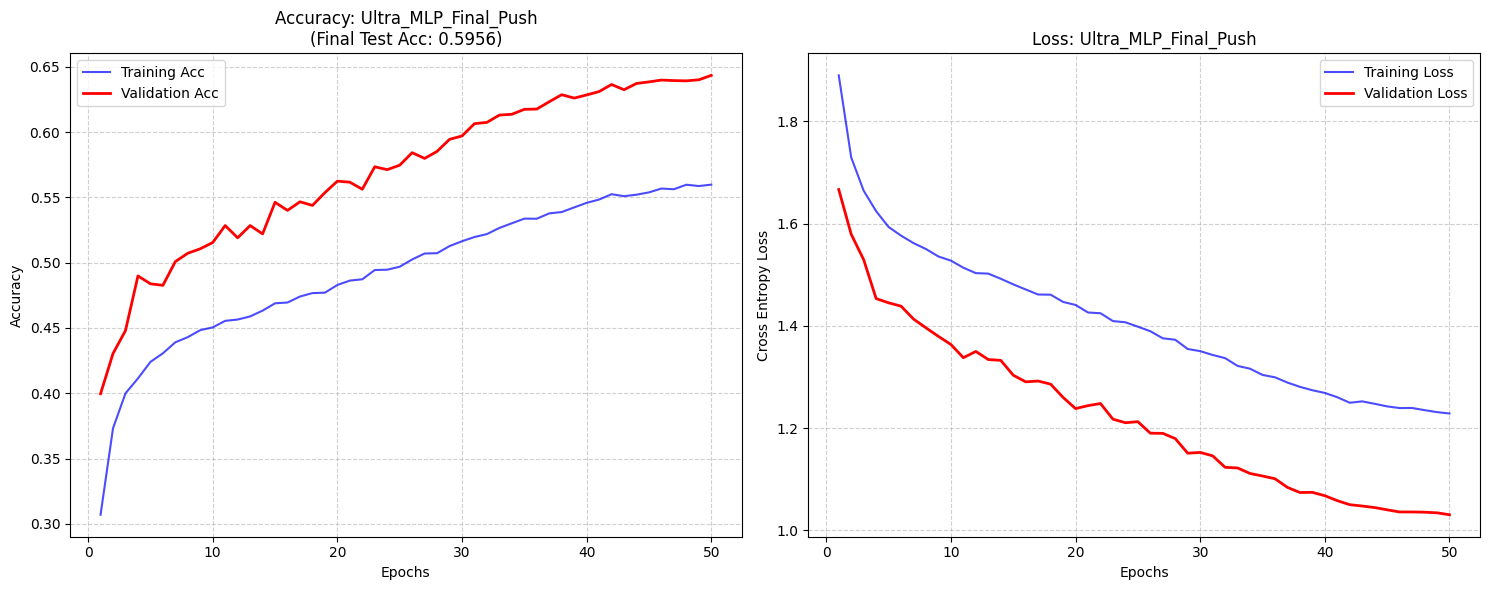

📈 Plot saved to: outputs/improved/ultra_performance_curves.png


In [ ]:
# 1. Load the results
with open("ultra_mlp_results.pkl", "rb") as f:
    ultra_log = pickle.load(f)

# Get the specific experiment data
exp_name = "Ultra_MLP_Final_Push"
data = ultra_log[exp_name]
history = data['history']
epochs = range(1, len(history['train_acc']) + 1)

# 2. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy
ax1.plot(epochs, history['train_acc'], 'b-', label='Training Acc', alpha=0.7)
ax1.plot(epochs, history['val_acc'], 'r-', label='Validation Acc', linewidth=2)
ax1.set_title(f'Accuracy: {exp_name}\n(Final Test Acc: {data["test_acc"]:.4f})')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss
ax2.plot(epochs, history['train_loss'], 'b-', label='Training Loss', alpha=0.7)
ax2.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
ax2.set_title(f'Loss: {exp_name}')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Cross Entropy Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("outputs/improved/ultra_performance_curves.png")
plt.show()

print(f"📈 Plot saved to: outputs/improved/ultra_performance_curves.png")

In [ ]:
# --- 1. Setup & Persistence ---
ULTRA_SAVE_DIR = Path("outputs/improved/ultra")
ULTRA_SAVE_DIR.mkdir(parents=True, exist_ok=True)
ULTRA_RESULTS_FILE = "ultra_mlp_results.pkl"

try:
    with open(ULTRA_RESULTS_FILE, "rb") as f:
        ultra_log = pickle.load(f)
except FileNotFoundError:
    ultra_log = {}

print("\n✅ All Ultra experiments completed without iteration errors.")


🚀 Starting High-Performance Trial: Ultra_LeakyReLU...
🎯 Achievement Unlocked: Ultra_LeakyReLU | Test Acc: 0.6024

🚀 Starting High-Performance Trial: Ultra_GeLU...
🎯 Achievement Unlocked: Ultra_GeLU | Test Acc: 0.6232

✅ All Ultra experiments completed without iteration errors.


## End of Notebook

All data analysis and visualization cells have been executed. 

- **Inline plots**: All plots are displayed inline in the notebook using `%matplotlib inline`.
- **Saved outputs**: All plots are also saved to the `outputs/` folder with descriptive filenames.
- **Training & testing**: The `train()` and `test()` functions are ready to use with your model definitions.
- **Model templates**: Uncomment and implement the `VanillaMLP` and `ImprovedMLP` classes as needed.